# Insurance Pricing — Frequency Model

This notebook trains a **claim frequency** model: the expected number of claims per unit of exposure (policy-year).

Claim frequency is modelled with a **Poisson distribution** because:
- Claims are non-negative integer events within a defined exposure period
- The log link keeps predicted frequencies strictly positive
- The Poisson deviance is the natural loss for count data weighted by exposure

## Approach: Frozen Estimator (Transfer Learning)

Rather than training a single model from scratch, we use a **two-stage approach**:

| Stage | Model | Description |
|-------|-------|-------------|
| **Base** | `PoissonRegressor` | Trained on a reference feature set — simulates a model built from publicly available or regulatory data |
| **Challenger** | `XGBoost (count:poisson)` + GridSearchCV | Uses base model predictions as a frozen feature, then layers proprietary features on top |

The key mechanism is `FrozenTransformer`: it wraps the base model so that its
predictions become an additional input column in the challenger's `FeatureUnion`.
The base model is **never retrained** during the challenger fit.

This pattern is useful when:
- A well-calibrated base model exists from a different (larger/external) dataset
- You want to learn a residual correction on top of the base prediction
- You need to keep the base model frozen for regulatory or auditability reasons

> **Prerequisite:** Run `python data/generate_data.py` to create `data/insurance_data.csv`.

In [1]:
import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_poisson_deviance

from xgboost import XGBRegressor

from transformers import (
    FeatureSelectorValues,
    ComputeAgeFromDOB,
    ComputeVehicleAge,
    FrozenTransformer,
)

## 00. Load Data

In [2]:
data = pd.read_csv("data/insurance_data.csv")

print(f"Shape: {data.shape}")
print(f"\nPortfolio statistics:")
print(f"  Policies with ≥1 claim : {(data['n_claims'] > 0).sum():,} ({(data['n_claims'] > 0).mean():.1%})")
print(f"  Total claims           : {data['n_claims'].sum():,}")
print(f"  Total exposure (yrs)   : {data['exposure'].sum():,.1f}")
print(f"  Observed frequency     : {data['n_claims'].sum() / data['exposure'].sum():.4f} claims/year")
data.head(3)

Shape: (50000, 17)

Portfolio statistics:
  Policies with ≥1 claim : 829 (1.7%)
  Total claims           : 839
  Total exposure (yrs)   : 27,054.8
  Observed frequency     : 0.0310 claims/year


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,exposure,n_claims,claim_amount
0,1999-02-25,2019,18029.894275,-21.282761,-44.993525,R14,CAT07,A,T2,4.021611,0.177176,0.227176,29.600459,61.930953,0.9851,0,0.0
1,1981-02-17,2007,19626.798130,-11.307904,-44.162892,R14,CAT05,B,T3,1.669606,0.375910,0.134073,43.424911,91.870299,0.9172,0,0.0
2,1950-11-29,2010,82790.024687,-23.816785,-37.258837,R03,CAT03,A,T2,6.828839,0.393362,0.054663,34.772980,52.442388,0.9841,0,0.0


C:\Users\sheil\AppData\Local\Temp\ipykernel_26440\2795776698.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["n_claims"].sum() / g["exposure"].sum())


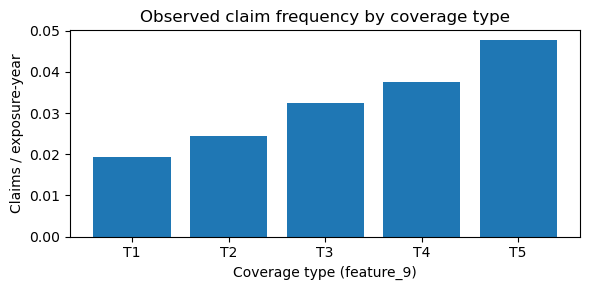

In [3]:
# Observed frequency by coverage type — sanity check that feature_9 is a risk driver
freq_by_cov = (
    data.groupby("feature_9")
    .apply(lambda g: g["n_claims"].sum() / g["exposure"].sum())
    .rename("observed_frequency")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(freq_by_cov["feature_9"], freq_by_cov["observed_frequency"])
ax.set_xlabel("Coverage type (feature_9)")
ax.set_ylabel("Claims / exposure-year")
ax.set_title("Observed claim frequency by coverage type")
plt.tight_layout()
plt.show()

## 01. Prepare Target and Split

The Poisson model predicts the **annual claim rate** (`n_claims / exposure`).
Exposure enters as `sample_weight`, which is equivalent to the offset term
in a classical GLM formulation.

In [4]:
y = data["n_claims"] / data["exposure"]   # annual claim rate
w = data["exposure"]                       # sample weight = exposure

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    data, y, w, test_size=0.20, random_state=42
)
for df_ in [X_train, X_test, y_train, y_test, w_train, w_test]:
    df_.reset_index(drop=True, inplace=True)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 40,000  |  Test: 10,000


## 02. Base Model (Reference Dataset)

The base model is a Poisson GLM trained on a **reference feature set** — the
subset of features that would typically be available in a publicly available
or regulatory dataset (geographic and product-level features).

In practice, this base model might come from a regulatory body, an industry
pool, or a prior model version. Here it is trained in-notebook for
self-containedness and then immediately frozen.

In [5]:
# Reference feature set: what a regulatory / industry-pool model might have access to
# (geographic coordinates, geo-numerical enrichment, and coverage type)
base_preprocessing = FeatureUnion(transformer_list=[
    ("numerical", Pipeline([
        ("selector", FeatureSelectorValues(["feature_3", "feature_4", "feature_5"])),
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
    ])),
    ("coverage", Pipeline([
        ("selector", FeatureSelectorValues(["feature_9"])),
        ("imputer",  SimpleImputer(strategy="most_frequent")),
        ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])),
    ("geo", Pipeline([
        ("selector", FeatureSelectorValues(
            ["feature_10", "feature_11", "feature_12", "feature_13", "feature_14"]
        )),
        ("imputer",  SimpleImputer(strategy="constant", fill_value=0)),
    ])),
])

base_model = Pipeline([
    ("preprocessing", base_preprocessing),
    ("model",         PoissonRegressor(alpha=1.0, max_iter=300)),
])

base_model.fit(X_train, y_train, model__sample_weight=w_train)
print("Base model (Poisson GLM) — training complete.")

base_pred_test = base_model.predict(X_test)
print(f"Base — Poisson deviance (test): "
      f"{mean_poisson_deviance(y_test, base_pred_test, sample_weight=w_test):.5f}")

Base model (Poisson GLM) — training complete.
Base — Poisson deviance (test): 0.24971


In [6]:
os.makedirs("models", exist_ok=True)
joblib.dump(base_model, "models/base_frequency.pkl")
print("Base model saved → models/base_frequency.pkl")

Base model saved → models/base_frequency.pkl


## 03. Challenger Pipeline (Frozen Estimator)

The challenger pipeline extends the base model with proprietary features.
The `FrozenTransformer` wraps the pre-trained base model so that its
predictions flow as a feature column into the `FeatureUnion` — alongside
all other sub-pipelines. The base model's weights are **never updated**.

```
FeatureUnion
├── base_predictions  ← FrozenTransformer(base_model) → SimpleImputer
├── age               ← ComputeAgeFromDOB → SimpleImputer → StandardScaler
├── vehicle_age       ← ComputeVehicleAge → SimpleImputer → StandardScaler
├── numerical         ← feature_3,4,5 → SimpleImputer → StandardScaler
├── region            ← feature_6 → SimpleImputer → OneHotEncoder
├── vehicle_category  ← feature_7 → SimpleImputer → OneHotEncoder
├── binary            ← feature_8 → SimpleImputer → OneHotEncoder
├── coverage          ← feature_9 → SimpleImputer → OneHotEncoder
└── geo               ← feature_10–14 → SimpleImputer(0)
        ↓
    XGBRegressor(objective='count:poisson')
```

Feature treatment rationale:

| Feature | Treatment | Rationale |
|---------|-----------|----------|
| `feature_1` (DOB) | → age → impute median → scale | Age computed at score time to avoid temporal drift |
| `feature_2` (model year) | → vehicle age → impute median → scale | Derived at score time for the same reason |
| `feature_3,4,5` | impute median → scale | Robust to heavy-tailed value/geo distributions |
| `feature_6` (region, 20 lvls) | impute mode → one-hot | `handle_unknown='ignore'` handles unseen regions at scoring |
| `feature_7` (vehicle cat, 10 lvls) | impute mode → one-hot | Vehicle type is a primary risk driver |
| `feature_8` (binary) | impute mode → one-hot | Policyholder attribute |
| `feature_9` (coverage, 5 lvls) | impute mode → one-hot | Coverage tier correlates with risk profile |
| `feature_10–14` (geo-numerical) | impute 0 | External enrichment; 0 = neutral effect for missing |


In [7]:
# Load the frozen base model
base_model = joblib.load("models/base_frequency.pkl")

# --- Sub-pipelines ---

# Base model predictions as a feature (frozen — not retrained)
base_predictions_pipeline = Pipeline([
    ("frozen_predictor", FrozenTransformer(base_model)),
    ("imputer",          SimpleImputer(strategy="median")),
])

# feature_1: policyholder DOB → age
# Younger policyholders carry higher frequency; computed at score time
# to prevent the feature from becoming stale between training and scoring.
age_pipeline = Pipeline([
    ("compute_age", ComputeAgeFromDOB(dob_column="feature_1")),
    ("imputer",     SimpleImputer(strategy="median")),
    ("scaler",      StandardScaler()),
])

# feature_2: vehicle model year → vehicle age
# Older vehicles tend toward higher frequency (wear, older safety equipment).
vehicle_age_pipeline = Pipeline([
    ("compute_veh_age", ComputeVehicleAge(year_column="feature_2")),
    ("imputer",         SimpleImputer(strategy="median")),
    ("scaler",          StandardScaler()),
])

# features 3, 4, 5: insured value and geographic coordinates
numerical_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(["feature_3", "feature_4", "feature_5"])),
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
])

# feature_6: geographic region (20 levels)
# Regional risk patterns vary substantially due to infrastructure, theft rates,
# and weather. handle_unknown='ignore' zeros unseen regions at scoring time.
region_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(["feature_6"])),
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# feature_7: vehicle category (10 levels)
vehicle_cat_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(["feature_7"])),
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# feature_8: binary categorical attribute
binary_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(["feature_8"])),
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# feature_9: coverage type (5 levels T1–T5)
# Higher coverage tiers correlate with higher risk profiles.
coverage_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(["feature_9"])),
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# features 10–14: geo-numerical enrichment (density, economic indicators)
# External features with higher expected missingness in production;
# imputing with 0 approximates a neutral/average effect.
geo_pipeline = Pipeline([
    ("selector", FeatureSelectorValues(
        ["feature_10", "feature_11", "feature_12", "feature_13", "feature_14"]
    )),
    ("imputer",  SimpleImputer(strategy="constant", fill_value=0)),
])

# Assemble: base model predictions + all proprietary features
preprocessing_challenger = FeatureUnion(transformer_list=[
    ("base_predictions", base_predictions_pipeline),  # ← frozen base model
    ("age",              age_pipeline),
    ("vehicle_age",      vehicle_age_pipeline),
    ("numerical",        numerical_pipeline),
    ("region",           region_pipeline),
    ("vehicle_category", vehicle_cat_pipeline),
    ("binary",           binary_pipeline),
    ("coverage",         coverage_pipeline),
    ("geo",              geo_pipeline),
])

challenger_pipeline = Pipeline([
    ("preprocessing", preprocessing_challenger),
    ("model", XGBRegressor(
        objective="count:poisson",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    )),
])

print("Challenger pipeline assembled.")
print(f"  Branches in FeatureUnion: {len(preprocessing_challenger.transformer_list)}")
print(f"  First branch = FrozenTransformer (base model predictions)")

Challenger pipeline assembled.
  Branches in FeatureUnion: 9
  First branch = FrozenTransformer (base model predictions)


## 04. Train Challenger (GridSearchCV)

We tune XGBoost hyperparameters with 3-fold cross-validation scored on
Poisson deviance. The `model__sample_weight` argument passes exposure
weights through the Pipeline to the model's `fit()` call.

In [8]:
params_freq = {
    "model__n_estimators":     [30, 60, 100, 150],
    "model__learning_rate":    [0.01, 0.10, 0.15, 0.20],
    "model__min_child_weight": [1, 3, 10, 15, 20],
    "model__subsample":        [0.8, 1.0],
    "model__colsample_bytree": [1.0],
    "model__max_depth":        [3, 5, 8],
}

challenger_cv = GridSearchCV(
    estimator=challenger_pipeline,
    param_grid=params_freq,
    scoring="neg_mean_poisson_deviance",
    cv=3,
    verbose=1,
    n_jobs=-1,
)

challenger_cv.fit(X_train, y_train, model__sample_weight=w_train)

Fitting 3 folds for each of 480 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [1.0], 'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_poisson_deviance'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [9]:
print(f"Best CV Poisson deviance : {-challenger_cv.best_score_:.5f}")
print("\nBest parameters:")
for k, v in challenger_cv.best_params_.items():
    print(f"  {k:35s}: {v}")

Best CV Poisson deviance : 0.26245

Best parameters:
  model__colsample_bytree            : 1.0
  model__learning_rate               : 0.15
  model__max_depth                   : 3
  model__min_child_weight            : 1
  model__n_estimators                : 30
  model__subsample                   : 0.8


## 05. Evaluate and Compare

In [10]:
challenger_best = challenger_cv.best_estimator_

base_pred_test        = base_model.predict(X_test)
challenger_pred_test  = challenger_best.predict(X_test)

dev_base       = mean_poisson_deviance(y_test, base_pred_test,       sample_weight=w_test)
dev_challenger = mean_poisson_deviance(y_test, challenger_pred_test, sample_weight=w_test)

print("Mean Poisson Deviance — test set (lower is better)")
print(f"  Base model (GLM, reference features)         : {dev_base:.5f}")
print(f"  Challenger (XGBoost + frozen base + all feat): {dev_challenger:.5f}")
print(f"  Improvement                                  : {(dev_base - dev_challenger) / dev_base:.1%}")

Mean Poisson Deviance — test set (lower is better)
  Base model (GLM, reference features)         : 0.24971
  Challenger (XGBoost + frozen base + all feat): 0.24831
  Improvement                                  : 0.6%


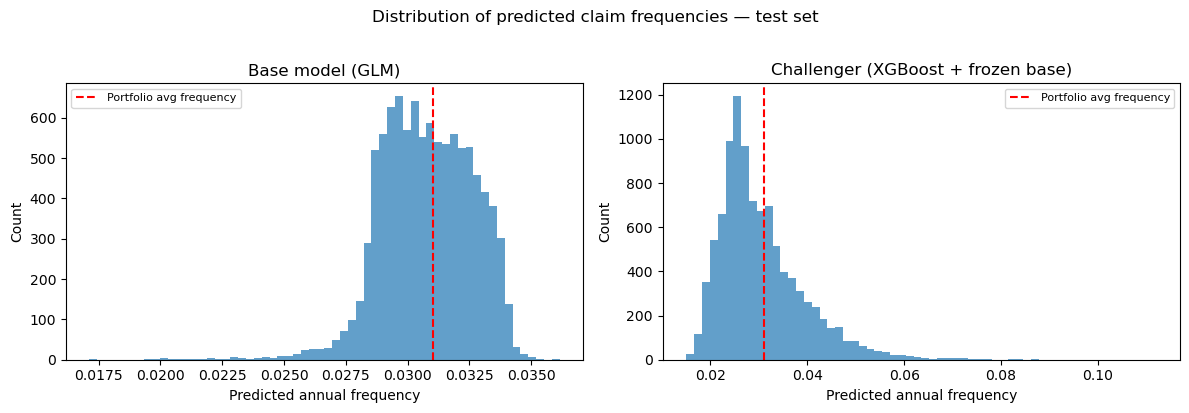

In [11]:
# Distribution of predicted frequencies on the test set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(
    axes,
    [base_pred_test, challenger_pred_test],
    ["Base model (GLM)", "Challenger (XGBoost + frozen base)"],
):
    ax.hist(preds, bins=60, edgecolor="none", alpha=0.7)
    ax.axvline(
        data["n_claims"].sum() / data["exposure"].sum(),
        color="red", linestyle="--", label="Portfolio avg frequency"
    )
    ax.set_xlabel("Predicted annual frequency")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle("Distribution of predicted claim frequencies — test set", y=1.02)
plt.tight_layout()
plt.show()

## 06. Save Models and Test Predictions

Challenger model is serialised with `joblib`. Test predictions are saved to
`data/freq_predictions.csv` for use in `02_severity_model.ipynb` and
`03_validation.ipynb`.

In [12]:
joblib.dump(challenger_best, "models/challenger_frequency.pkl")
print("Challenger saved → models/challenger_frequency.pkl")

os.makedirs("data", exist_ok=True)
freq_predictions = pd.DataFrame({
    "n_claims":     X_test["n_claims"].values,
    "claim_amount": X_test["claim_amount"].values,
    "exposure":     w_test.values,
    "freq_base":    base_pred_test,        # GLM base rate prediction
    "freq_challenger": challenger_pred_test,  # XGBoost + frozen base rate prediction
})
freq_predictions.to_csv("data/freq_predictions.csv", index=False)
print(f"Test predictions saved → data/freq_predictions.csv ({len(freq_predictions):,} rows)")

Challenger saved → models/challenger_frequency.pkl
Test predictions saved → data/freq_predictions.csv (10,000 rows)
